In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("/content/drive/MyDrive/DATASETS/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# **BASIC INFO ABOUT DATASET**

In [41]:
df.shape

(7043, 21)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [44]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# **EDA**

In [46]:
from IPython.core import error
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [47]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [48]:
df.dropna(inplace=True)

In [49]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [50]:
df["Churn"].value_counts(normalize=True)
#Class Imbalance

,proportion
Churn,
No,0.734215
Yes,0.265785


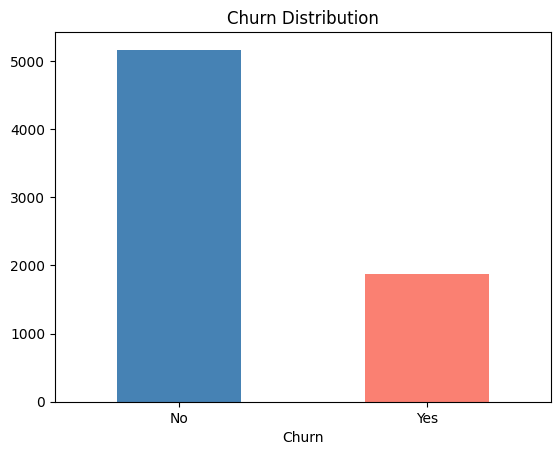

In [51]:
df["Churn"].value_counts().plot(kind="bar",color=["steelblue","salmon"])
plt.title("Churn Distribution")
plt.xticks(rotation=0)
plt.show()

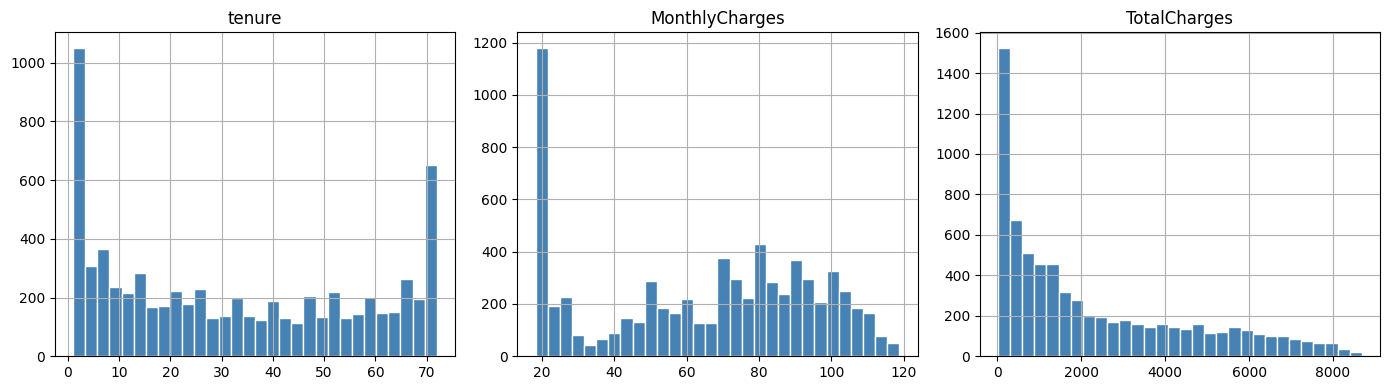

In [52]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].describe()

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

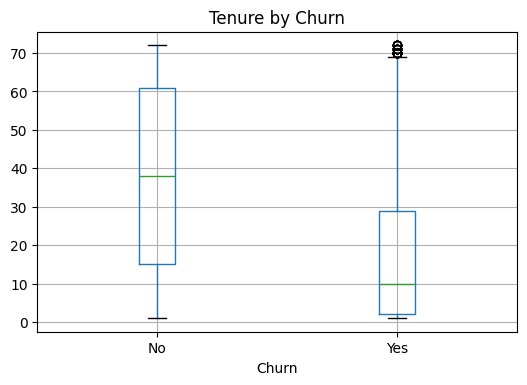

In [53]:
df.boxplot(column='tenure', by='Churn', figsize=(6, 4))
plt.title('Tenure by Churn')
plt.suptitle('')
plt.show()

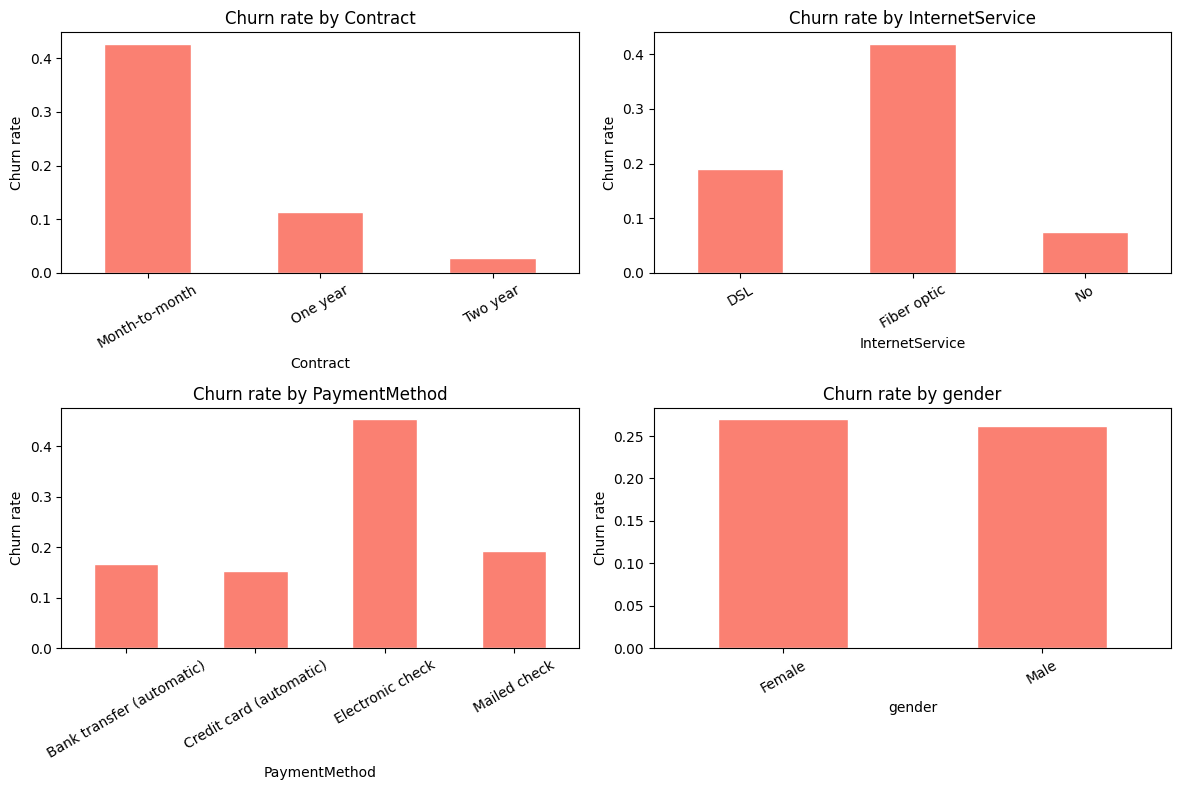

In [54]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(cat_cols):
    ax = axes[i//2][i%2]
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean())
    churn_rate.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

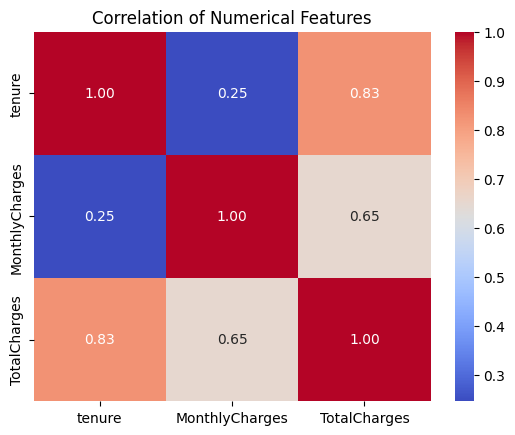

In [55]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Numerical Features')
plt.show()

# **PRE-PROCESSING**

In [56]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [58]:
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling",'Churn']

from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()

for col in binary_cols:
  df[col]=le.fit_transform(df[col])



In [59]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [60]:
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [61]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [63]:
df.drop("customerID",axis=1,inplace=True)

In [64]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,...,False,False,False,False,False,False,False,False,True,False


# **TRAIN-TEST-SPLIT**

In [65]:
X = df.drop("Churn",axis=1)
y = df["Churn"]

In [67]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X_train, y_train,
                         cv=skf, scoring='f1')

print("F1 per fold:", scores.round(3))
print("Mean F1:", scores.mean().round(3))
print("Std Dev:", scores.std().round(3))

F1 per fold: [0.621 0.574 0.564 0.601 0.62 ]
Mean F1: 0.596
Std Dev: 0.024


In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='f1')
    print(f"{name}: Mean F1 = {scores.mean():.3f} | Std = {scores.std():.3f}")

Logistic Regression: Mean F1 = 0.596 | Std = 0.024
KNN: Mean F1 = 0.549 | Std = 0.016
Naive Bayes: Mean F1 = 0.587 | Std = 0.006


# **Model Implementation**

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'        : GaussianNB()
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model

In [71]:
for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC Score: 0.836

  KNN
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1033
       Churn       0.55      0.58      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.76      1407

ROC-AUC Score: 0.786

  Naive Bayes
              precision    recall  f1-score   support

    No Churn       0.92      0.57      0.70      1033
       Churn       0.42      0.86      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.

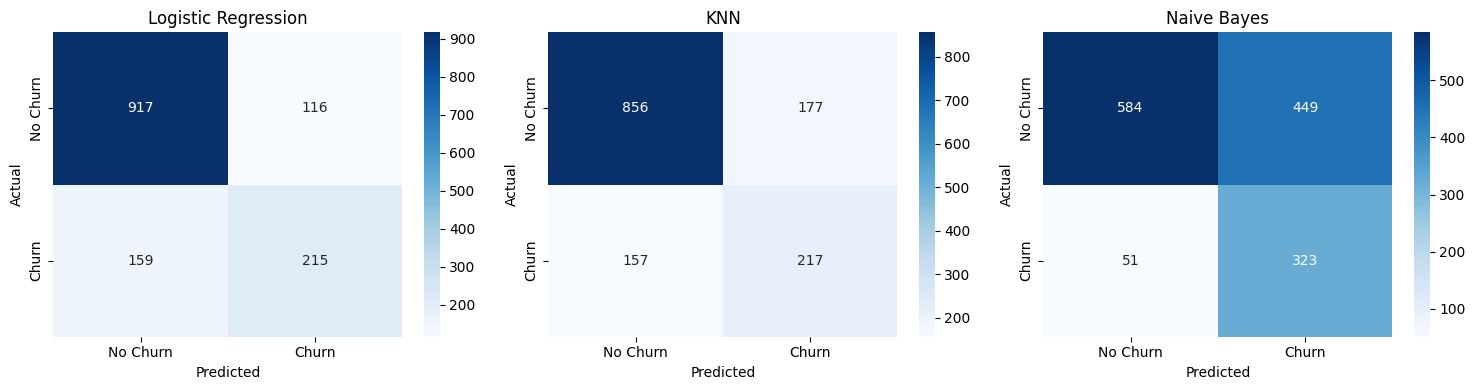

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

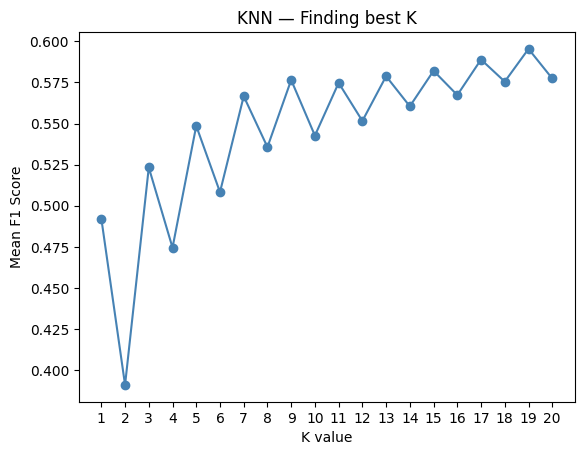

Best K: 19


In [73]:
k_scores = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train,
                            cv=skf, scoring='f1').mean()
    k_scores.append(score)

plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.xlabel('K value')
plt.ylabel('Mean F1 Score')
plt.title('KNN — Finding best K')
plt.xticks(k_range)
plt.show()

best_k = k_range[k_scores.index(max(k_scores))]
print(f"Best K: {best_k}")

In [74]:
trained['KNN'] = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)

In [75]:
for C, penalty in [(0.01, 'l2'), (0.1, 'l2'), (1.0, 'l2'), (1.0, 'l1')]:
    lr = LogisticRegression(C=C, penalty=penalty,
                            solver='liblinear', max_iter=1000)
    score = cross_val_score(lr, X_train, y_train,
                            cv=skf, scoring='f1').mean()
    print(f"C={C}, penalty={penalty} → F1: {score:.3f}")

C=0.01, penalty=l2 → F1: 0.575
C=0.1, penalty=l2 → F1: 0.589
C=1.0, penalty=l2 → F1: 0.595
C=1.0, penalty=l1 → F1: 0.595


In [76]:
results = []
for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred,
                                   output_dict=True)
    results.append({
        'Model'    : name,
        'Precision': round(report['1']['precision'], 3),
        'Recall'   : round(report['1']['recall'], 3),
        'F1'       : round(report['1']['f1-score'], 3),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Precision  Recall    F1  ROC-AUC
Logistic Regression      0.650   0.575 0.610    0.836
                KNN      0.595   0.570 0.582    0.820
        Naive Bayes      0.418   0.864 0.564    0.810
